In [197]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [198]:
train_data = pd.read_csv("fashion-mnist_train.csv")
train_data = np.array(train_data)
m, n = train_data.shape
X_pixels = train_data[:,1::] # pixel RGB values
y_labels = train_data[:,0] # type of clothing
X_train = X_pixels[:int(n*0.8)].T # (784, 628)
X_train = X_train / 255.0
y_train = y_labels[:int(n*0.8)] # (1, 628)
y_train = np.eye(10)[y_train].T # one hot encoding


In [199]:
test_data = pd.read_csv("fashion-mnist_test.csv")
test_data = np.array(test_data)
X_pixels = test_data[:,1::] # pixel RGB values
y_labels = test_data[:,0] # type of clothing
X_test = X_pixels[:int(n*0.8)].T # (784, 628)
X_test = X_test / 255.0
y_test = y_labels[:int(n*0.8)] # (1, 628)
y_test = np.eye(10)[y_test].T # one hot encoding

In [200]:
def relu(X):
  return X if (X > 0).any() else 0

def relu_deriv(X):
  return 1 if (X > 0).any() else 0

def softmax(X):
  return np.exp(X) / np.sum(np.exp(X), axis=0, keepdims=True)

In [201]:
def init_params(hidden_size):
    w1 = np.random.randn(hidden_size, 784) * np.sqrt(2 / 784)
    b1 = 0
    w2 = np.random.randn(10, hidden_size) * np.sqrt(1 / hidden_size)
    b2 = 0
    return w1, b1, w2, b2

def forward_propagation(w1, b1, w2, b2, X):
    z1 = np.dot(w1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = softmax(z2)   
    return z1, a1, z2, a2

def calculate_loss(X, y, a2):
    m = X.shape[1]
    result = -1 / m * (np.sum(y * np.log(a2 + 1e-8)))
    return result
    
def back_propagation(z1, a1, a2, X, y, w2):
    m = X.shape[1]
    dz2 = a2 - y #(32,) (10,628) 
    dw2 = 1 / m * np.dot(dz2, a1.T)
    db2 = 1 / m * np.sum(dz2)
    dz1 = np.dot(w2.T, dz2) * relu_deriv(z1)
    dw1 = 1 / m * np.dot(dz1, X.T)
    db1 = 1 / m * np.sum(dz1)
    return db1, db2, dw1, dw2
    
def update_params(w1, b1, w2, b2, alpha, dw1, db1, dw2, db2):
    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1

    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2

    return w1, b1, w2, b2


In [233]:
def get_pred(a2): 
    preds = np.argmax(a2, axis=0)
    return preds

def get_accuracy(preds, y):
    true_labels = np.argmax(y, axis=0)
    return np.mean(preds == true_labels)


In [234]:
def gradient_desc(X, y, alpha, iterations):
    w1, b1, w2, b2 = init_params(hidden_size=32)
    for i in range(iterations):
        z1, a1, z2, a2 = forward_propagation(w1, b1, w2, b2, X)
        db1, db2, dw1, dw2 = back_propagation(z1, a1, a2, X, y, w2)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, alpha, dw1, db1, dw2, db2)
        if i % 20 == 0:
            print(f"Iteration {i} | Acc: {get_accuracy(get_pred(a2), y):.2f} | Loss: {calculate_loss(X_train, y_train, a2)}")
    return w1, b1, w2, b2
 
    


In [235]:
w1, b1, w2, b2 = gradient_desc(X_train, y_train, 0.01, 1000)

Iteration 0 | Acc: 0.12 | Loss: 2.513501628263755
Iteration 20 | Acc: 0.34 | Loss: 2.033966489309854
Iteration 40 | Acc: 0.47 | Loss: 1.8228549644464045
Iteration 60 | Acc: 0.57 | Loss: 1.653552196947274
Iteration 80 | Acc: 0.61 | Loss: 1.5122969033884692
Iteration 100 | Acc: 0.65 | Loss: 1.393393451452278
Iteration 120 | Acc: 0.67 | Loss: 1.2932990589076447
Iteration 140 | Acc: 0.68 | Loss: 1.2091609577889133
Iteration 160 | Acc: 0.69 | Loss: 1.13838453589158
Iteration 180 | Acc: 0.70 | Loss: 1.07860488312382
Iteration 200 | Acc: 0.71 | Loss: 1.0277559155883753
Iteration 220 | Acc: 0.72 | Loss: 0.9841111930467571
Iteration 240 | Acc: 0.74 | Loss: 0.9462748159857653
Iteration 260 | Acc: 0.74 | Loss: 0.9131401397808728
Iteration 280 | Acc: 0.74 | Loss: 0.883837618015768
Iteration 300 | Acc: 0.76 | Loss: 0.8576849709198602
Iteration 320 | Acc: 0.76 | Loss: 0.8341450813963887
Iteration 340 | Acc: 0.76 | Loss: 0.8127925350281958
Iteration 360 | Acc: 0.77 | Loss: 0.7932878325933973
Iteratio

Predicted label: Dress
Actual label: Shirt


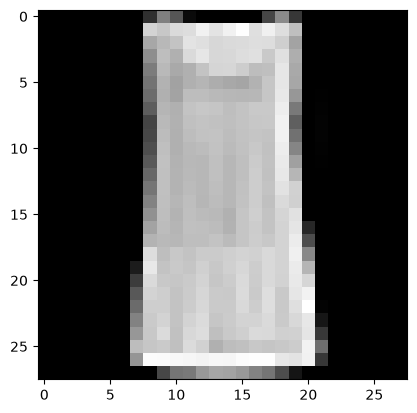

In [253]:
labels = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
rng = np.random.default_rng()
test_index = rng.integers(low=0, high=X_test.shape[1])
z1test, a1test, z2test, a2test = forward_propagation(w1, b1, w2, b2, X_test[:, test_index, None])
print(f"Predicted label: {labels[get_pred(a2test).item()]}")
print(f"Actual label: {labels[np.argmax(y_test[:, test_index])]}")

image_array = X_test[:, test_index].reshape(28,28)
plt.imshow(image_array, cmap="grey")
plt.show()